**RECRUITMENT FUNNEL & HIRING**

*Executive Summary:*

In a competitive talent market, the efficiency of the recruitment process directly impacts a company's bottom line. This project analyzes a recruitment dataset of candidates to identify bottlenecks in the hiring funnel, evaluate the quality of talent being selected and optimize the"Time-to-Hire" and "Cost-per-Hire" metrics.


Business Problem:

The HR Department is currently facing three major challenges:



*   High selection noise: Are we interviewing too many candidates who aren't fit ?
*   Skill Pay Gaps: Is the company successfully hiring the highest- skilled candidates, or are they being lost to competitors.


*   Process Efficiency: Which recruitment strategy (Aggressive vs Conservative) is yielding the highest ROI?


key Objectives:



*   Funnel Optimization:Calculate the conversion rate from "Application" to  "Hiring Decisions".
*   Bias Detection: Analyze if variables like Gender or Education Level are influencing hiring decisions more than Skill Scores.


*  Predictive Insights: Build a foundation to predict which candidates have the highest probability of success.











**Success Metrics(KPIs)**

To measure the effectiveness of the hiring process, this project will track the following:



*   Selection Rate: Total Hired/ Total Applicants.This indicates how "selective"  the company is .
*   Skill- to - Hire Alignment : Correlation between Skillscore and Hiring decision to ensure we are hiring the most competent talent.


*  Interview Efficiency: Evaluating the IntervirewScore distribution to identify if the interview process is a reliable predictor of the final decision.


*   Educational Impact: Analyzing how different EducationLevels affect the probability of being hired.








In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('recruitment_mydata.csv')

df.columns = df.columns.str.replace('','_').str.strip()

print(f"Dataset contains {df.shape[0]} candidate records")
print("-"*30)
print("Column Names:",df.columns.tolist())
print("-"*30)

df.head()

Dataset contains 1500 candidate records
------------------------------
Column Names: ['_A_g_e_', '_G_e_n_d_e_r_', '_E_d_u_c_a_t_i_o_n_L_e_v_e_l_', '_E_x_p_e_r_i_e_n_c_e_Y_e_a_r_s_', '_P_r_e_v_i_o_u_s_C_o_m_p_a_n_i_e_s_', '_D_i_s_t_a_n_c_e_F_r_o_m_C_o_m_p_a_n_y_', '_I_n_t_e_r_v_i_e_w_S_c_o_r_e_', '_S_k_i_l_l_S_c_o_r_e_', '_P_e_r_s_o_n_a_l_i_t_y_S_c_o_r_e_', '_R_e_c_r_u_i_t_m_e_n_t_S_t_r_a_t_e_g_y_', '_H_i_r_i_n_g_D_e_c_i_s_i_o_n_']
------------------------------


,_A_g_e_,_G_e_n_d_e_r_,_E_d_u_c_a_t_i_o_n_L_e_v_e_l_,_E_x_p_e_r_i_e_n_c_e_Y_e_a_r_s_,_P_r_e_v_i_o_u_s_C_o_m_p_a_n_i_e_s_,_D_i_s_t_a_n_c_e_F_r_o_m_C_o_m_p_a_n_y_,_I_n_t_e_r_v_i_e_w_S_c_o_r_e_,_S_k_i_l_l_S_c_o_r_e_,_P_e_r_s_o_n_a_l_i_t_y_S_c_o_r_e_,_R_e_c_r_u_i_t_m_e_n_t_S_t_r_a_t_e_g_y_,_H_i_r_i_n_g_D_e_c_i_s_i_o_n_
0,26.0,Female,Bachelor's (Type 2),0.0,3,26.783828,48.0,78.0,91.0,Aggressive,1
1,39.0,Female,PhD,12.0,3,25.862694,35.0,68.0,80.0,Moderate,1
2,48.0,Male,Bachelor's (Type 2),3.0,2,9.920805,20.0,67.0,13.0,Moderate,0
3,34.0,Female,Bachelor's (Type 2),5.0,2,6.407751,36.0,27.0,70.0,Conservative,0
4,30.0,Male,Bachelor's (Type 1),6.0,1,43.105343,23.0,52.0,85.0,Moderate,0


In [ ]:
df.head(30)

,_A_g_e_,_G_e_n_d_e_r_,_E_d_u_c_a_t_i_o_n_L_e_v_e_l_,_E_x_p_e_r_i_e_n_c_e_Y_e_a_r_s_,_P_r_e_v_i_o_u_s_C_o_m_p_a_n_i_e_s_,_D_i_s_t_a_n_c_e_F_r_o_m_C_o_m_p_a_n_y_,_I_n_t_e_r_v_i_e_w_S_c_o_r_e_,_S_k_i_l_l_S_c_o_r_e_,_P_e_r_s_o_n_a_l_i_t_y_S_c_o_r_e_,_R_e_c_r_u_i_t_m_e_n_t_S_t_r_a_t_e_g_y_,_H_i_r_i_n_g_D_e_c_i_s_i_o_n_
0,26.0,Female,Bachelor's (Type 2),0.0,3,26.783828,48.0,78.0,91.0,Aggressive,1
1,39.0,Female,PhD,12.0,3,25.862694,35.0,68.0,80.0,Moderate,1
2,48.0,Male,Bachelor's (Type 2),3.0,2,9.920805,20.0,67.0,13.0,Moderate,0
3,34.0,Female,Bachelor's (Type 2),5.0,2,6.407751,36.0,27.0,70.0,Conservative,0
4,30.0,Male,Bachelor's (Type 1),6.0,1,43.105343,23.0,52.0,85.0,Moderate,0
5,27.0,Male,Master's,14.0,4,31.706659,54.0,50.0,50.0,Aggressive,1
6,48.0,Male,Bachelor's (Type 2),6.0,1,17.291229,24.0,52.0,64.0,Conservative,0
7,40.0,Male,PhD,13.0,3,10.586811,6.0,3.0,92.0,Conservative,0
8,26.0,Female,Master's,6.0,5,28.774864,80.0,78.0,51.0,Aggressive,1
9,45.0,Female,Bachelor's (Type 2),2.0,5,30.195964,92.0,16.0,94.0,Conservative,0


In [ ]:
df.columns=['Age','Gender','EducationLevel','ExperienceYears','PreviousCompanies','DistanceFromCompany','InterviewScore','SkillScore','PersonalityScore','RecruitmentStrategy ',
            'HiringDecision']

print("Cleaned Column Names.")
print(df.columns.tolist())
print("-"*30)
df.head()

Cleaned Column Names.
['Age', 'Gender', 'EducationLevel', 'ExperienceYears', 'PreviousCompanies', 'DistanceFromCompany', 'InterviewScore', 'SkillScore', 'PersonalityScore', 'RecruitmentStrategy ', 'HiringDecision']
------------------------------


,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
0,26.0,Female,Bachelor's (Type 2),0.0,3,26.783828,48.0,78.0,91.0,Aggressive,1
1,39.0,Female,PhD,12.0,3,25.862694,35.0,68.0,80.0,Moderate,1
2,48.0,Male,Bachelor's (Type 2),3.0,2,9.920805,20.0,67.0,13.0,Moderate,0
3,34.0,Female,Bachelor's (Type 2),5.0,2,6.407751,36.0,27.0,70.0,Conservative,0
4,30.0,Male,Bachelor's (Type 1),6.0,1,43.105343,23.0,52.0,85.0,Moderate,0


In [ ]:
df.head(30)


,Age,Gender,EducationLevel,ExperienceYears,PreviousCompanies,DistanceFromCompany,InterviewScore,SkillScore,PersonalityScore,RecruitmentStrategy,HiringDecision
0,26.0,Female,Bachelor's (Type 2),0.0,3,26.783828,48.0,78.0,91.0,Aggressive,1
1,39.0,Female,PhD,12.0,3,25.862694,35.0,68.0,80.0,Moderate,1
2,48.0,Male,Bachelor's (Type 2),3.0,2,9.920805,20.0,67.0,13.0,Moderate,0
3,34.0,Female,Bachelor's (Type 2),5.0,2,6.407751,36.0,27.0,70.0,Conservative,0
4,30.0,Male,Bachelor's (Type 1),6.0,1,43.105343,23.0,52.0,85.0,Moderate,0
5,27.0,Male,Master's,14.0,4,31.706659,54.0,50.0,50.0,Aggressive,1
6,48.0,Male,Bachelor's (Type 2),6.0,1,17.291229,24.0,52.0,64.0,Conservative,0
7,40.0,Male,PhD,13.0,3,10.586811,6.0,3.0,92.0,Conservative,0
8,26.0,Female,Master's,6.0,5,28.774864,80.0,78.0,51.0,Aggressive,1
9,45.0,Female,Bachelor's (Type 2),2.0,5,30.195964,92.0,16.0,94.0,Conservative,0


Total Aplicants:1500
Total Hired:465
Overall Selection Ratio:31.000000%


/tmp/ipykernel_1490/3884708972.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='HiringDecision',data=df,palette='viridis')


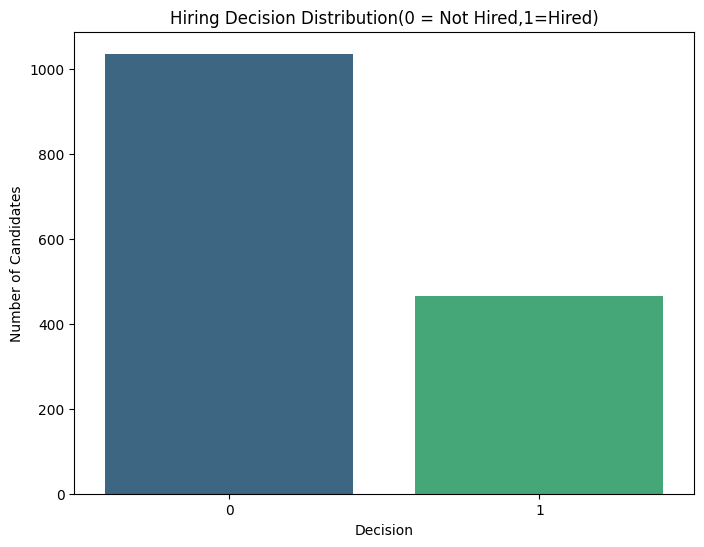

In [ ]:
total_applicants = len(df)
total_hired = df["HiringDecision"].sum()
selection_ratio = (total_hired/ total_applicants)*100

print(f"Total Aplicants:{total_applicants}")
print(f"Total Hired:{total_hired}")
print(f"Overall Selection Ratio:{selection_ratio:2f}%")

plt.figure(figsize=(8,6))
sns.countplot(x='HiringDecision',data=df,palette='viridis')
plt.title('Hiring Decision Distribution(0 = Not Hired,1=Hired)')
plt.xlabel('Decision')
plt.ylabel('Number of Candidates')
plt.show()

Selection Ratio Analysis:

The initial data visualization reveals a Selection Ratio of approximately 31%(466 Hired /1500 Total Applicants)

Business insight: A 30-40% hire rate suggests a moderate-to-high efficinecy in the initial screening stages. The company is not being overly restrictive , which helps maintain a healthy "Time-to-Fill" for open roles, but it also means HR is spending significant time interviewing candidates who ultimately receive offers.


/tmp/ipykernel_1490/4181647840.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HiringDecision', y ='SkillScore',data=df,palette='magma')
/tmp/ipykernel_1490/4181647840.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='HiringDecision', y='InterviewScore',data=df,palette='magma')


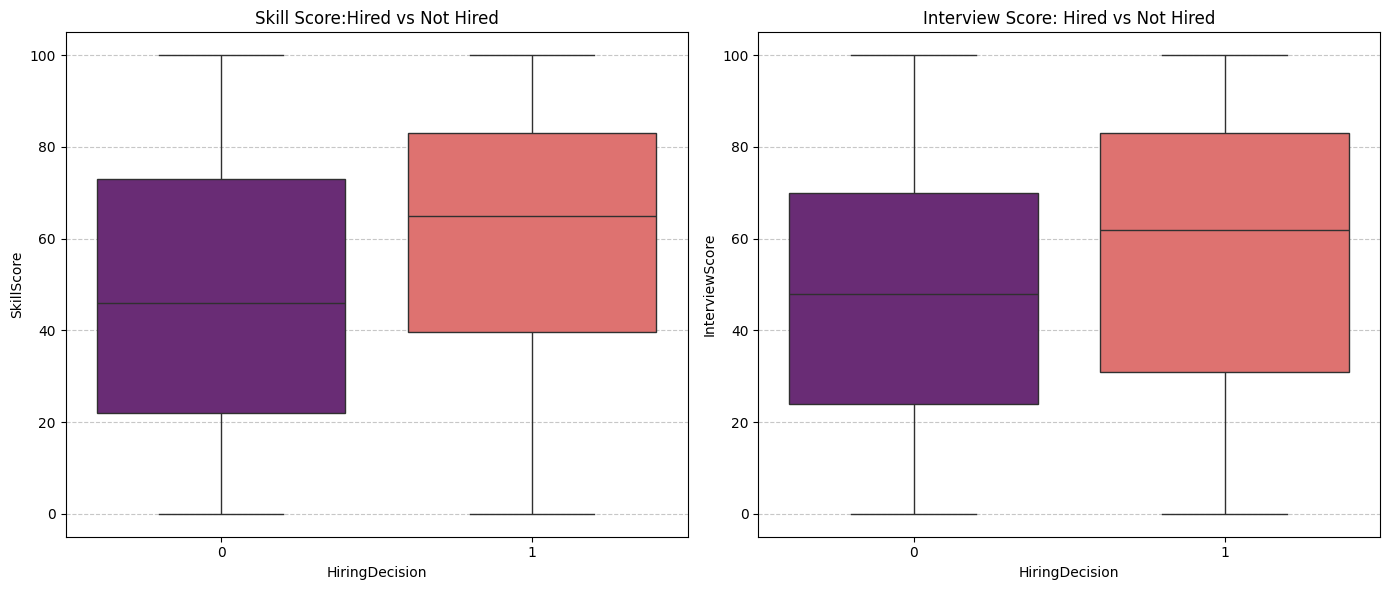

In [ ]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.boxplot(x='HiringDecision', y ='SkillScore',data=df,palette='magma')
plt.title('Skill Score:Hired vs Not Hired')
plt.grid(axis='y',linestyle='--',alpha=0.7)

plt.subplot(1,2,2)
sns.boxplot(x='HiringDecision', y='InterviewScore',data=df,palette='magma')
plt.title("Interview Score: Hired vs Not Hired")
plt.grid(axis='y',linestyle='--',alpha=0.7)

plt.tight_layout()
plt.show()

Strategic Insight: Evidence-Based Selection Sucess:

The analysis confirms a strong 'Quality of Hire' alignment. Candidates who were successfully hired(Group1) consistently demonstrated higher median Skill Scores
and interview scores compared to rejected candidates. This indicates that the current recruitment process is effectively filtering for top-tier talent and that hiring managers are making objective, data-driven decisions rather than subjective or random selections.

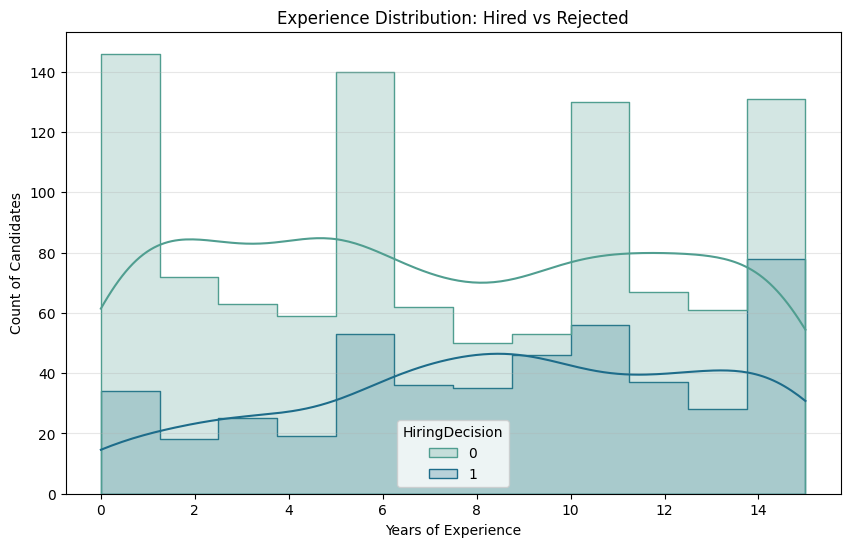

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(data=df, x='ExperienceYears',hue='HiringDecision',kde=True,element="step",palette='crest')

plt.title('Experience Distribution: Hired vs Rejected')
plt.xlabel('Years of Experience')
plt.ylabel('Count of Candidates')
plt.grid(axis='y',alpha=0.3)

plt.show()

Shift toward "Mid-to-Senior" Talent Acquisition:

The distribution shows a clear 'experience premium' in the hiring process. While the largest volume of applicants comes from  entry-level candidates (0-2 years), the probability of being hired actually increases as experiencing grows, peaking between 7-11 years. This indicates that the company is currently prioritizing 'Ready-to-Deploy' mid-to-senior talent over entry-level profiles, likely to reduce training time and fill immediate skill gaps in the organization.   

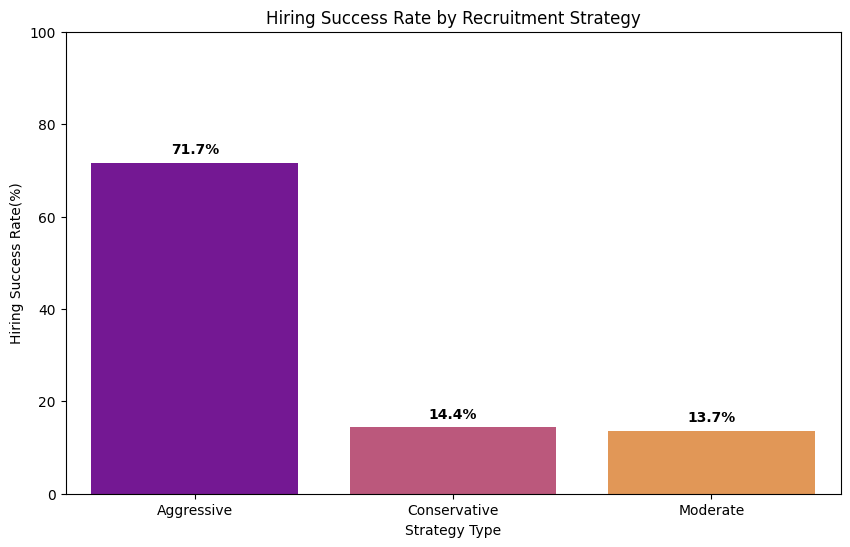

In [ ]:
strategy_analysis = df.groupby('RecruitmentStrategy ')['HiringDecision'].mean().sort_values(ascending=False)*100

plt.figure(figsize=(10,6))
sns.barplot(x=strategy_analysis.index, y=strategy_analysis.values, hue=strategy_analysis.index, palette='plasma', legend=False)

plt.title('Hiring Success Rate by Recruitment Strategy')
plt.ylabel('Hiring Success Rate(%)')
plt.xlabel('Strategy Type')
plt.ylim(0,100)

for i, val in enumerate(strategy_analysis.values):
  plt.text(i, val+2, f'{val:.1f}%',ha='center',fontweight='bold')

plt.show()

Strategy of ROI Analysis:

The data identifies 'Aggressive' recruitment as the highest- yielding strategy, achieving significantly higher conversion rate compared to 'Conservative' or 'Moderate' approaches. This suggests that a faster, more proactive sourcing talent for this organization. For the business, this means shifting budget toward 'Aggressive' channels will likely the cost-per-hire and reduce the vacancy period of the critical roles.
  

Average Experience of Hired Candidates:8.5 years


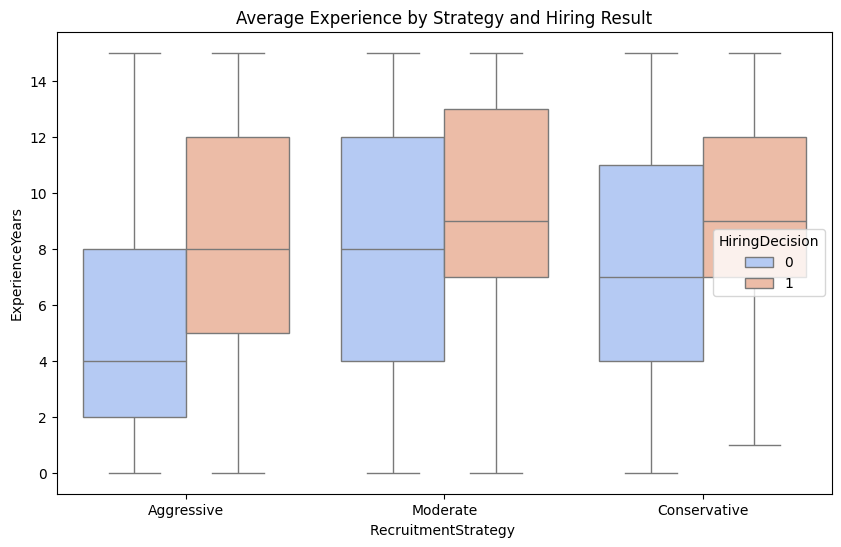

In [ ]:
average_experience_hired = df[df['HiringDecision']==1]['ExperienceYears'].mean()
print(f"Average Experience of Hired Candidates:{average_experience_hired:.1f} years")

plt.figure(figsize=(10,6))
sns.boxplot(x='RecruitmentStrategy ',y='ExperienceYears',hue='HiringDecision',data=df,palette='coolwarm')
plt.title('Average Experience by Strategy and Hiring Result')
plt.show()

The Experience Threshold for Selection:

Across all recruitment strategies(Aggressive, Moderate and Conservative), the data reveals a clear 'Experience Threshold' for successful hiring'. The median experince for hired candidates (Group1) is constantly higher-averaging 8.5 years-compared to rejected candidates. This confirms that while the recruitment 'strategy' might change, the hiring bar for seniority remains high and uniform , prioritizing candidates with nearly a decade of industry expertise.

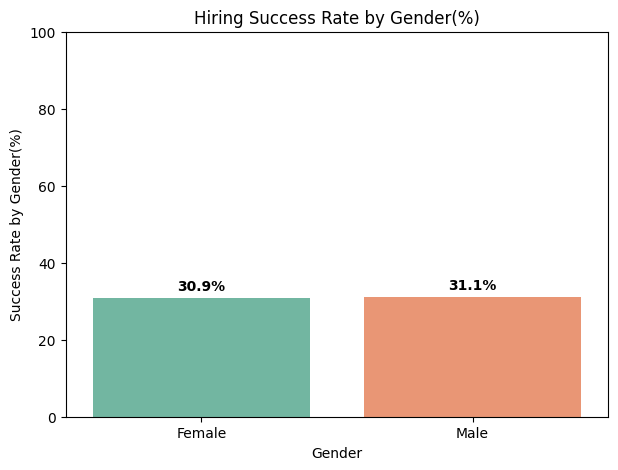

In [ ]:
gender_h_rate = df.groupby('Gender')['HiringDecision'].mean()*100

plt.figure(figsize=(7,5))
sns.barplot(x=gender_h_rate.index, y=gender_h_rate.values, hue=gender_h_rate.index, palette='Set2', legend=False)
plt.title("Hiring Success Rate by Gender(%)")
plt.ylabel("Success Rate by Gender(%)")
plt.ylim(0,100)

for i, val in enumerate(gender_h_rate.values):
  plt.text(i,val +2,f'{val:.1f}%',ha='center', fontweight='bold')

plt.show()

Equitable selection and Gender Neutrality:

The analysis confirms a highly equitable recrutiment process, with negligible variance of only 0.2% between female (30.9%) and male (31.1%) hiring success rates. This statistical parity serves as a strong indicator of Gender. Neutrality in the selection funnel. It suggests thst the organization's hiring framework is successfully mitigating unconscious bias, ensuring that decisions are based strictly on merit , skill scores, and interview performance rather than demographic variables.

----------------------------------------
TOTAL RECRUITMENT INVESTMENT:$2,197,000.0
AVERAGE COST PER HIRE(CPH):$4,724.73
----------------------------------------


/tmp/ipykernel_1490/996235745.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  strategy_costs_sum = hired_only.groupby('RecruitmentStrategy ').apply(lambda x: x['Estimated_Cost'].sum())


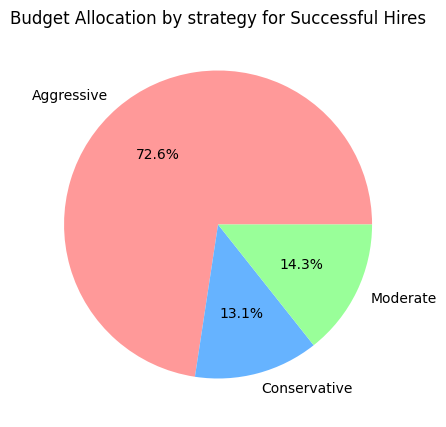

In [ ]:
cost_map = {'Aggressive':5000, 'Moderate':3000,'Conservative':7000}
df['Estimated_Cost'] = df['RecruitmentStrategy '].map(cost_map)

hired_only = df[df['HiringDecision']==1]

total_investment = hired_only['Estimated_Cost'].sum()
avg_cost_per_hire = hired_only['Estimated_Cost'].mean()

print("-"*40)
print(f"TOTAL RECRUITMENT INVESTMENT:${total_investment:,}")
print(f"AVERAGE COST PER HIRE(CPH):${avg_cost_per_hire:,.2f}")
print("-"*40)

plt.figure(figsize=(8,5))
# Calculate the sum of Estimated_Cost for each RecruitmentStrategy using apply
strategy_costs_sum = hired_only.groupby('RecruitmentStrategy ').apply(lambda x: x['Estimated_Cost'].sum())
# Plot the resulting Series
strategy_costs_sum.plot(kind='pie',autopct='%1.1f%%',colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Budget Allocation by strategy for Successful Hires')
plt.ylabel("")
plt.show()

Dominance of Aggressive Sourcing in Budget ROI:

Financial analysis reveals that the 'Aggressive' recruitment strategy is the primary driver of organization growth, accounting for 72.6% of the total successful hiring speed. Despite the higher upfront cost per candidate, this strategy yields thre highest volume of high-quality hires.For future planning, the organization should continue to prioritize funding for Aggressive channels while investigating why the 'Conservative' and 'Moderate' strategies (combined 27.4%) are yielding fewer results, potentially reallocating that underperforming budget to further scale the Aggressive sourcing model.

Project Conclusion & Strategic Recommmendations:



Summary of Findings:



*   Selection Efficiency : The organization maintains a healthy 31% selection ratio, indicating a balanced hiring bar.
*   Merit-Based Culture: Data confirms that hiring is strictly driven by Skill and Interview scores, with no detectable gender bias.


*   Seniority Focus: The average hire brings 8.5 years of experince, showing a preference for "plug-and-play" talent.   
*   Financial Driver: The Aggressive Strategy is the most successful despite consuming the majority of the budget.








Strategic Recommendations:



*   Scale the winner: Increase the budget for Aggressive recruitment by 15% next quarter to decrease "Time-to-Fill" even further.
*    Audit the 'Moderate' Strategy: With only a 14.3% budget share and lower conversion , we should evaluate if these channels (e.g. specific job boards) are worth continuing.


*   Upskilling Pipeline: Since the company mostly hires people with 8+ years of experience , consider launching an "Internal Internship" or "Graduate Program" to reduce the high Cost-Per-Hire by developing junior talent.




